# DataForSEO Topic Graph - DAG Analysis

This notebook analyzes the DataForSEO topic graph as a Directed Acyclic Graph (DAG) using NetworkX.

In [50]:
#conda install -c conda-forge numpy scikit-learn
#!pip install -U umap-learn scikit-learn


In [51]:
import json
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict
import pprint
import umap

## Load the Topic Graph

In [52]:
# Load the JSON file
#JSON = '../deepfabric-dataforseo-blog/dataforseo-topic-graph.jsonl'
JSON = '../seo-graph-10tools-single.json'

with open(JSON, 'r') as file:
    data = json.load(file)

print(f"Total nodes: {len(data['nodes'])}")
print(f"Root ID: {data.get('root_id', 'N/A')}")

Total nodes: 156
Root ID: 0


## Build NetworkX DiGraph from Topic Data

In [53]:
import networkx as nx
from collections import deque

# Create a directed graph
G = nx.DiGraph()

# Add nodes 
for node_id, node_data in data['nodes'].items():
    G.add_node(
        str(node_id),
        topic=node_data.get('topic', ''),
        metadata=node_data.get('metadata', {})
    )

    # Add edges from parent to children
    for child_id in node_data.get('children', []):
        G.add_edge(str(node_id), str(child_id))

# Compute depth
roots = [n for n in G.nodes if G.in_degree(n) == 0]
for root in roots:
    G.nodes[root]['depth'] = 0
    queue = deque([(root, 0)])

    while queue:
        node, depth = queue.popleft()
        for child in G.successors(node):
            # Avoid overwriting if already set 
            if 'depth' not in G.nodes[child]:
                G.nodes[child]['depth'] = depth + 1
                queue.append((child, depth + 1))

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


Graph has 156 nodes and 198 edges


## Verify it's a Valid DAG

In [54]:
# Check if it's a DAG
is_dag = nx.is_directed_acyclic_graph(G)
print(f"Is this a valid DAG? {is_dag}")

if not is_dag:
    # Find cycles if any
    try:
        cycles = list(nx.simple_cycles(G))
        print(f"Found {len(cycles)} cycles")
        if cycles:
            print("First cycle:", cycles[0])
    except:
        print("Could not detect cycles")

Is this a valid DAG? True


## Display All Topics

In [55]:
# Display all topics with their properties
print("=" * 100)
for node_id in G.nodes():
    topic = G.nodes[node_id]['topic']
    depth = G.nodes[node_id]['depth']
    children_count = G.out_degree(node_id)  # Number of outgoing edges
    parents_count = G.in_degree(node_id)    # Number of incoming edges
    
    print(f"ID: {node_id:4s} | Depth: {depth} | Parents: {parents_count} | Children: {children_count:2d}")
    print(f"  Topic: {topic}")
    print()

ID: 0    | Depth: 0 | Parents: 0 | Children: 15
  Topic: Generate diverse SEO tasks using 10 core tools calling a single tool


ID: 1    | Depth: 1 | Parents: 1 | Children: 13
  Topic: Understanding Diverse SEO Task Categories

ID: 2    | Depth: 1 | Parents: 1 | Children: 14
  Topic: Key Features of the 10 Core SEO Tools

ID: 3    | Depth: 1 | Parents: 1 | Children: 13
  Topic: Designing the Single Orchestration Tool for SEO Task Management

ID: 4    | Depth: 1 | Parents: 1 | Children:  9
  Topic: Automated Workflow for Generating SEO Tasks

ID: 5    | Depth: 1 | Parents: 1 | Children:  9
  Topic: Benefits and Challenges of Unified SEO Task Generation

ID: 12   | Depth: 1 | Parents: 3 | Children:  5
  Topic: Improved Data Consistency and Reporting Across Tools

ID: 15   | Depth: 1 | Parents: 3 | Children:  5
  Topic: User Adoption and Training Requirements for the Single Tool

ID: 19   | Depth: 1 | Parents: 3 | Children:  5
  Topic: Monitoring and Reporting of Automated SEO Tasks

ID: 

## DAG Analysis - Basic Statistics

In [56]:
# Find root nodes (no incoming edges)
root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
print(f"Root nodes: {len(root_nodes)}")
for root in root_nodes:
    print(f"  - {root}: {G.nodes[root]['topic']}")

print()

# Find leaf nodes (no outgoing edges)
leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]
print(f"Leaf nodes: {len(leaf_nodes)}")
print(f"First 10 leaf topics:")
for leaf in leaf_nodes[:10]:
    print(f"  - {leaf}: {G.nodes[leaf]['topic']}")

Root nodes: 1
  - 0: Generate diverse SEO tasks using 10 core tools calling a single tool


Leaf nodes: 125
First 10 leaf topics:
  - 31: Core Components of the Orchestration Tool
  - 32: Scalability and High Availability Design
  - 33: Plugin and Extension Architecture
  - 34: Security Architecture and Mechanisms
  - 35: Integration with External Systems
  - 41: Input Data Types and Validation
  - 42: Output Data Structures and Serialization
  - 43: Parameterization and Dynamic Inputs
  - 44: Error Handling and Fallbacks for I/O
  - 45: Schema Definition and Metadata for I/O


## Topological Sort

In [57]:
# Get topological ordering (valid processing order)
if is_dag:
    topo_order = list(nx.topological_sort(G))
    print(f"Topological order (first 20 nodes):")
    for i, node_id in enumerate(topo_order[:20]):
        print(f"{i+1}. {node_id}: {G.nodes[node_id]['topic'][:80]}...")
else:
    print("Cannot perform topological sort on a graph with cycles")

Topological order (first 20 nodes):
1. 0: Generate diverse SEO tasks using 10 core tools calling a single tool
...
2. 1: Understanding Diverse SEO Task Categories...
3. 2: Key Features of the 10 Core SEO Tools...
4. 3: Designing the Single Orchestration Tool for SEO Task Management...
5. 4: Automated Workflow for Generating SEO Tasks...
6. 5: Benefits and Challenges of Unified SEO Task Generation...
7. 25: Emerging SEO Task Categories: Voice Search, AI, and Local SEO...
8. 21: Detailed Breakdown of On-Page SEO Task Categories...
9. 22: Exploring Off-Page SEO Task Categories and Strategies...
10. 23: Technical SEO Task Categories: Crawling, Indexing, and Performance...
11. 24: Understanding Keyword Research and Content Planning Task Categories...
12. 26: Keyword Research and Analysis Tool Features...
13. 29: Backlink Analysis and Link Building Features...
14. 6: Architecture of the Orchestration Tool...
15. 7: Defining Task Inputs and Outputs for Orchestration...
16. 8: Integration APIs

## Depth Level Analysis

In [58]:
# Group nodes by depth
depth_groups = defaultdict(list)
for node_id in G.nodes():
    depth = G.nodes[node_id]['depth']
    depth_groups[depth].append(node_id)

print("Nodes per depth level:")
for depth in sorted(depth_groups.keys()):
    print(f"  Depth {depth}: {len(depth_groups[depth])} nodes")

print(f"\nMaximum depth: {max(depth_groups.keys())}")

Nodes per depth level:
  Depth 0: 1 nodes
  Depth 1: 15 nodes
  Depth 2: 65 nodes
  Depth 3: 75 nodes

Maximum depth: 3


## Find Ancestors and Descendants

In [59]:
# Example: Find all ancestors and descendants of a specific node
# Change this to any node ID you're interested in
example_node = '1'  # First child of root

if example_node in G.nodes():
    print(f"Analyzing node {example_node}: {G.nodes[example_node]['topic']}")
    print()
    
    # Ancestors (all nodes that can reach this node)
    ancestors = nx.ancestors(G, example_node)
    print(f"Ancestors ({len(ancestors)}):")
    for anc in list(ancestors)[:5]:
        print(f"  - {anc}: {G.nodes[anc]['topic'][:60]}...")
    
    print()
    
    # Descendants (all nodes reachable from this node)
    descendants = nx.descendants(G, example_node)
    print(f"Descendants ({len(descendants)}):")
    for desc in list(descendants)[:5]:
        print(f"  - {desc}: {G.nodes[desc]['topic'][:60]}...")

Analyzing node 1: Understanding Diverse SEO Task Categories

Ancestors (1):
  - 0: Generate diverse SEO tasks using 10 core tools calling a sin...

Descendants (78):
  - 142: Website Performance and Core Web Vitals Monitoring...
  - 90: Methods for Dynamic Input Parameter Generation...
  - 155: Content Gap & Opportunity Analysis Tools...
  - 112: Social Media Marketing's Role in Off-Page SEO...
  - 132: AI-Powered Content Generation and SEO Analysis...


## Find Paths Between Nodes

In [60]:
# Find all paths from root to a leaf node
if root_nodes and leaf_nodes:
    root = root_nodes[0]
    leaf = leaf_nodes[0]
    
    if nx.has_path(G, root, leaf):
        # Get all simple paths
        all_paths = list(nx.all_simple_paths(G, root, leaf))
        print(f"Found {len(all_paths)} path(s) from root '{root}' to leaf '{leaf}'")
        print(f"\nFirst path:")
        for node in all_paths[0]:
            print(f"  → {node}: {G.nodes[node]['topic'][:70]}...")
        
        # Shortest path
        shortest = nx.shortest_path(G, root, leaf)
        print(f"\nShortest path length: {len(shortest)-1} edges")

Found 2 path(s) from root '0' to leaf '31'

First path:
  → 0: Generate diverse SEO tasks using 10 core tools calling a single tool
...
  → 2: Key Features of the 10 Core SEO Tools...
  → 6: Architecture of the Orchestration Tool...
  → 31: Core Components of the Orchestration Tool...

Shortest path length: 3 edges


## Visualize a Subgraph (Limited Depth)

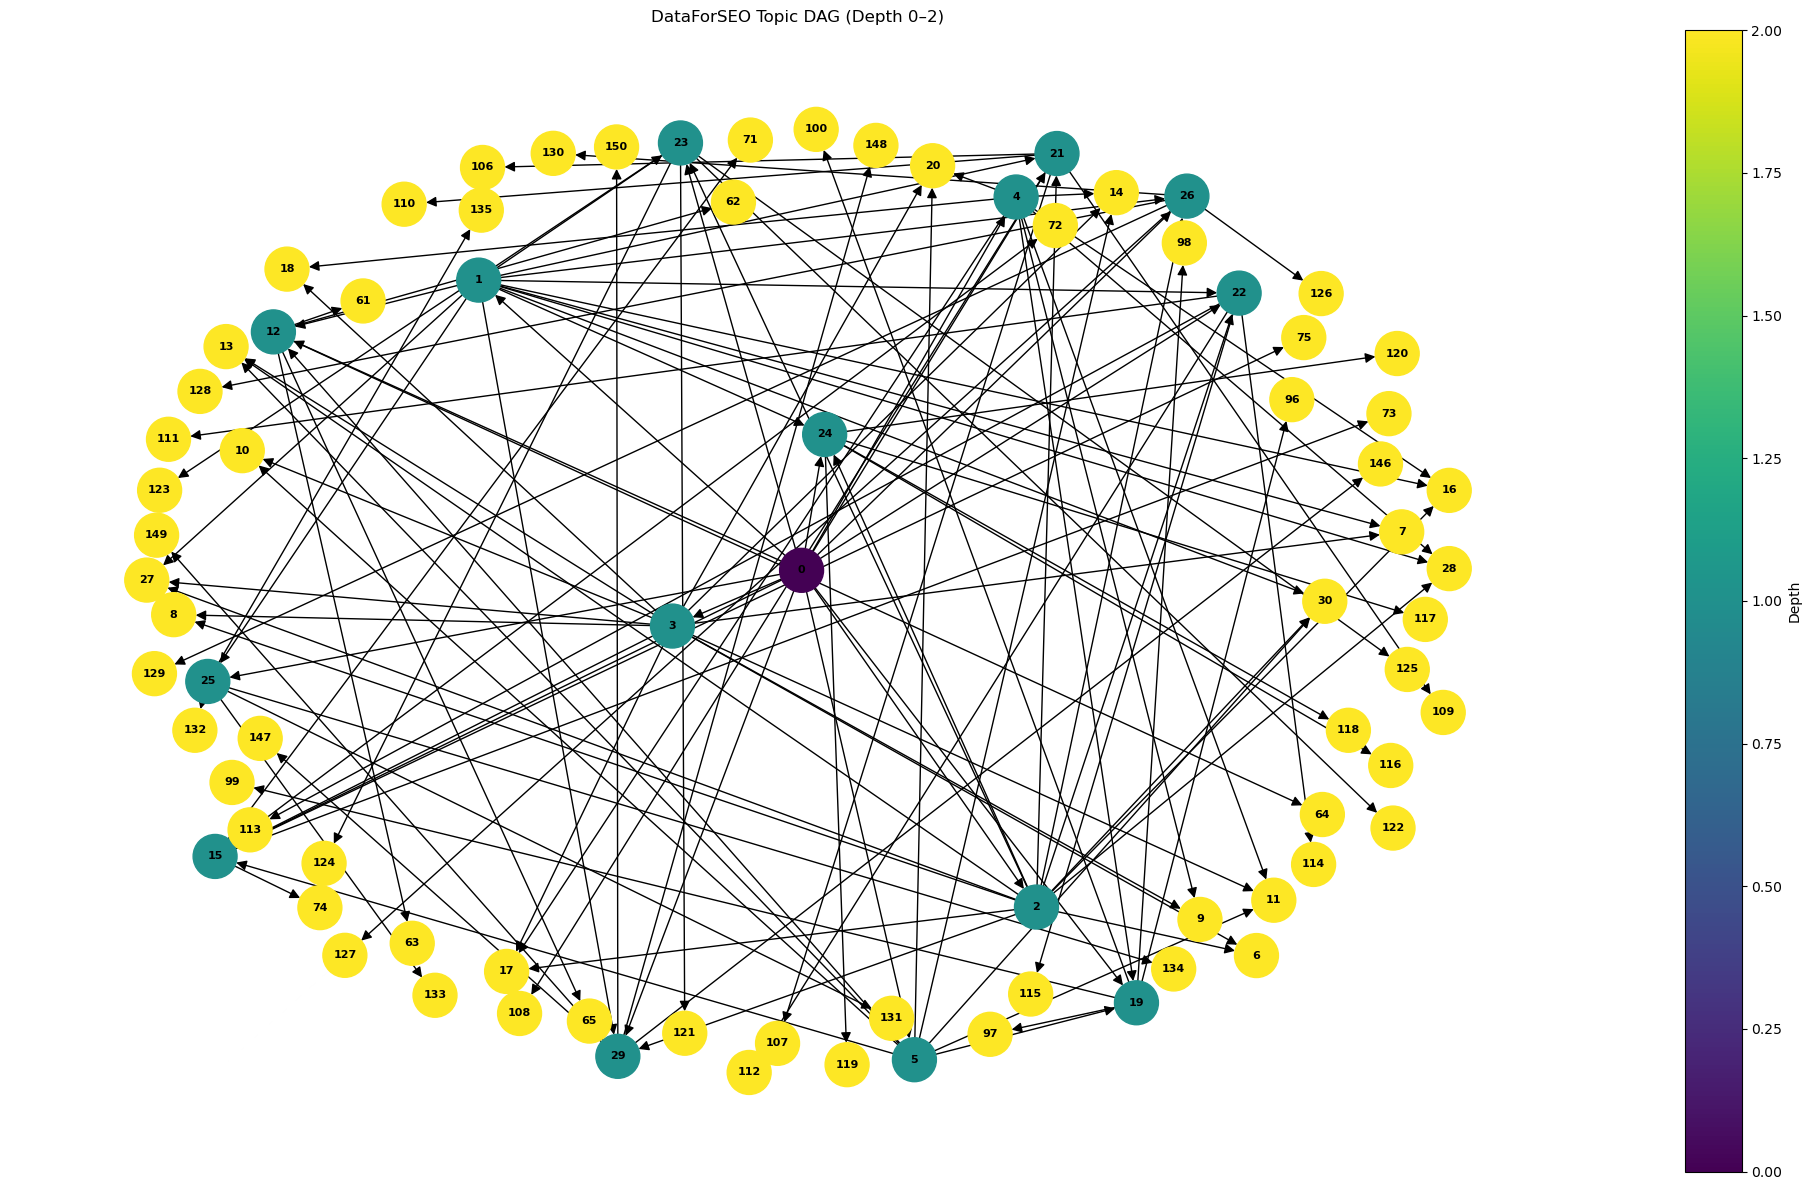

Visualized 81 nodes out of 156 total


In [61]:
# Visualize only nodes up to depth 2 for readability
MAX_DEPTH = 2
subgraph_nodes = [n for n in G.nodes() if G.nodes[n]['depth'] <= MAX_DEPTH]
subG = G.subgraph(subgraph_nodes)

fig, ax = plt.subplots(figsize=(20, 12))

pos = nx.spring_layout(subG, k=2, iterations=50)

# Color nodes by depth
node_colors = [G.nodes[n]['depth'] for n in subG.nodes()]

nx.draw(
    subG,
    pos,
    ax=ax,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    with_labels=True,
    labels={n: n for n in subG.nodes()},
    node_size=1000,
    font_size=8,
    font_weight='bold',
    arrows=True,
    arrowsize=15
)

ax.set_title(f"DataForSEO Topic DAG (Depth 0–{MAX_DEPTH})")

# Compute colorbar
norm = mpl.colors.Normalize(
    vmin=min(node_colors),
    vmax=max(node_colors)
)
sm = mpl.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label='Depth')

plt.tight_layout()
plt.show()

print(f"Visualized {len(subgraph_nodes)} nodes out of {G.number_of_nodes()} total")


## Interactive Visualization with PyVis

In [62]:
from pyvis.network import Network

# Create interactive visualization for limited depth
MAX_DEPTH_INTERACTIVE = 3
subgraph_nodes = [n for n in G.nodes() if G.nodes[n]['depth'] <= MAX_DEPTH_INTERACTIVE]
subG = G.subgraph(subgraph_nodes)

net = Network(height="800px", width="100%", notebook=True, directed=True)
net.barnes_hut()  # Use Barnes-Hut physics for better layout

# Add nodes with hover tooltips
for node in subG.nodes():
    topic = G.nodes[node]['topic']
    depth = G.nodes[node]['depth']
    net.add_node(node, 
                 label=f"{node}",
                 title=f"Depth {depth}: {topic}",
                 level=depth)  # Use depth for hierarchical layout

# Add edges
for u, v in subG.edges():
    net.add_edge(u, v)

# Set hierarchical layout
net.set_options("""
{
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "directed"
    }
  },
  "physics": {
    "hierarchicalRepulsion": {
      "centralGravity": 0.0
    }
  }
}
""")

net.show("dataforseo_dag_interactive.html")
print(f"Interactive visualization saved to dataforseo_dag_interactive.html")

dataforseo_dag_interactive.html
Interactive visualization saved to dataforseo_dag_interactive.html


# Analyse Quality

In [63]:

import json
import math
import random
from collections import defaultdict
from tqdm import tqdm

import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from pprint import pprint

In [64]:
EMBED_MODEL = "all-MiniLM-L6-v2"
K_NEIGHBORS = 50
SAMPLED_PAIRWISE = 5000
CLUSTER_K = None
SEED_ROOT_IDS = None  # or e.g. ['0']

# Thresholds (tune)
TAU_LNC = 0.50
TAU_NA = 0.40
TAU_GTD = 0.40
TAU_DUP = 0.92
TAU_NOVELTY = 0.20

# Severity weights (for ranking flagged nodes)
SEV_WEIGHTS = {"lnc": 0.35, "gtd": 0.35, "dup": 0.2, "novelty": 0.1}

In [65]:
# Utilities (normalization, cosine)
def normalize_to_01(arr, eps=1e-12):
    a = np.array(arr, dtype=float)
    lo = np.nanmin(a)
    hi = np.nanmax(a)
    if math.isclose(hi, lo):
        return np.clip((a - lo), 0.0, 1.0)
    return (a - lo) / (hi - lo + eps)

def cosine_sim_matrix_rowwise(A, B=None):
    if B is None:
        B = A
    A_n = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B_n = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return A_n.dot(B_n.T)


In [66]:
# Load graph JSON & build networkx DiGraph (returns G, raw_json)
def load_graph_from_json(path):
    with open(path, 'r', encoding='utf-8') as fh:
        data = json.load(fh)
    nodes = data['nodes']
    G = nx.DiGraph()
    for node_id, nd in nodes.items():
        key = str(node_id)
        G.add_node(key,
                   topic=nd.get('topic', '').strip(),
                   metadata=nd.get('metadata', {}),
                   parents=[str(p) for p in nd.get('parents', [])],
                   children=[str(c) for c in nd.get('children', [])])
    # edges
    for n in list(G.nodes):
        for c in G.nodes[n]['children']:
            if c in G.nodes:
                G.add_edge(n, c)
    # compute depth
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    if not roots:
        roots = ["0"] if "0" in G.nodes else [list(G.nodes)[0]]
    for root in roots:
        G.nodes[root]['depth'] = 0
        queue = [root]
        while queue:
            cur = queue.pop(0)
            cur_depth = G.nodes[cur].get('depth', 0)
            for child in G.successors(cur):
                if 'depth' not in G.nodes[child]:
                    G.nodes[child]['depth'] = cur_depth + 1
                    queue.append(child)
    return G, data

G, raw = load_graph_from_json(JSON)
print(G)

DiGraph with 156 nodes and 198 edges


In [67]:
# Compute embeddings (stores in node attribute 'embedding') and returns model
def compute_embeddings(G, model_name=EMBED_MODEL):
    node_list = list(G.nodes)
    texts = [G.nodes[n]['topic'] if G.nodes[n]['topic'] else G.nodes[n]['metadata'].get('title','') for n in node_list]
    for i, t in enumerate(texts):
        if t is None or t.strip() == '':
            texts[i] = G.nodes[node_list[i]]['metadata'].get('uuid', node_list[i])
    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
    for i, n in enumerate(node_list):
        G.nodes[n]['embedding'] = embeddings[i]
    return G, model


G, model = compute_embeddings(G)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [68]:
# Build kNN neighbors (returns dict: node -> list of (neighbor_id, sim))
def build_knn_index(G, k=K_NEIGHBORS):
    node_list = list(G.nodes)
    X = np.vstack([G.nodes[n]['embedding'] for n in node_list])
    k_eff = min(k + 1, len(node_list))
    nn = NearestNeighbors(n_neighbors=k_eff, metric='cosine').fit(X)
    dists, idxs = nn.kneighbors(X)
    sims = 1.0 - dists
    neighbors = {}
    for i, n in enumerate(node_list):
        rows = idxs[i].tolist()
        sims_row = sims[i].tolist()
        pairs = [(node_list[r], sims_row[j]) for j, r in enumerate(rows) if r != i]
        neighbors[n] = pairs[:k]
    return neighbors

neighbors = build_knn_index(G)
neighbors['0'][:5]  # preview

[('13', 0.7235976457595825),
 ('2', 0.6761926412582397),
 ('4', 0.6629635095596313),
 ('5', 0.6268789768218994),
 ('92', 0.6260323524475098)]

In [69]:
# Compute per-node metrics (returns dicts)
def compute_node_metrics(G, neighbors, seed_centroid=None):
    node_list = list(G.nodes)
    emb_map = {n: G.nodes[n]['embedding'] for n in node_list}
    lnc, na, gtd, max_sim, novelty = {}, {}, {}, {}, {}
    for n in node_list:
        neigh_pairs = neighbors.get(n, [])
        neigh_ids = [p[0] for p in neigh_pairs]
        neigh_sims = [p[1] for p in neigh_pairs]
        lnc[n] = float(np.mean(neigh_sims)) if neigh_sims else float('nan')
        if len(neigh_ids) < 2:
            na[n] = float('nan')
        else:
            M = np.vstack([emb_map[u] for u in neigh_ids])
            sims = cosine_sim_matrix_rowwise(M)
            k = sims.shape[0]
            triu = np.triu_indices(k, k=1)
            na[n] = float(np.mean(sims[triu])) if triu[0].size > 0 else float('nan')
        gtd[n] = float(np.dot(emb_map[n], seed_centroid)) if seed_centroid is not None else float('nan')
        max_sim[n] = max([s for (_, s) in neigh_pairs]) if neigh_pairs else 0.0

        parents = G.nodes[n].get('parents', [])
        siblings = []
        for p in parents:
            for c in G.nodes[p]['children']:
                if c != n:
                    siblings.append(c)
        comps = []
        if parents:
            comps += [np.dot(emb_map[n], emb_map[p]) for p in parents if p in emb_map]
        if siblings:
            comps += [np.dot(emb_map[n], emb_map[s]) for s in siblings if s in emb_map]
        novelty[n] = 1.0 - float(np.mean(comps)) if comps else 1.0

    return {"lnc": lnc, "na": na, "gtd": gtd, "max_sim": max_sim, "novelty": novelty}

node_metrics = compute_node_metrics(G, neighbors, seed_centroid=G.nodes['0']['embedding'])
pprint(list(node_metrics['lnc'].items())[:10]) # note: dict, sample accordingly


[('0', 0.4491955816745758),
 ('1', 0.44203314900398255),
 ('2', 0.5176918959617615),
 ('3', 0.4455894887447357),
 ('4', 0.5216263628005982),
 ('5', 0.4919906485080719),
 ('6', 0.31746204614639284),
 ('7', 0.3116499292850494),
 ('8', 0.3600478792190552),
 ('9', 0.3160321295261383)]


In [70]:
# Compute global metrics (coherence, diversity, etc.)
def compute_global_scores(G, node_metrics, neighbors, sample_pairs=SAMPLED_PAIRWISE, cluster_k=CLUSTER_K):
    node_list = list(G.nodes)
    N = len(node_list)
    emb_arr = np.vstack([G.nodes[n]['embedding'] for n in node_list])
    emb_arr = emb_arr.astype(np.float64, copy=False)

    lnc_vals = np.array([node_metrics['lnc'][n] for n in node_list], dtype=float)
    na_vals = np.array([node_metrics['na'][n] for n in node_list], dtype=float)
    gtd_vals = np.array([node_metrics['gtd'][n] for n in node_list], dtype=float)

    lnc_norm = normalize_to_01(np.nan_to_num(lnc_vals, nan=np.nan))
    na_norm = normalize_to_01(np.nan_to_num(na_vals, nan=np.nan))
    gtd_norm = normalize_to_01(np.nan_to_num(gtd_vals, nan=np.nan))
    coherence_global = float(np.nanmean([lnc_norm, na_norm, gtd_norm]))

    total_pairs = N*(N-1)//2
    pair_sims = []
    if total_pairs <= sample_pairs:
        sims = cosine_sim_matrix_rowwise(emb_arr)
        iu = np.triu_indices(N, 1)
        pair_sims = sims[iu].tolist()
    else:
        for _ in range(sample_pairs):
            i, j = random.randrange(N), random.randrange(N)
            while i == j:
                j = random.randrange(N)
            pair_sims.append(float(np.dot(emb_arr[i], emb_arr[j])))
    mean_pair_sim = float(np.mean(pair_sims))
    diversity_from_pair = 1.0 - mean_pair_sim

    if cluster_k is None:
        K = min(max(5, max(1, N // 50)), 50)
    else:
        K = cluster_k
    if N <= K:
        norm_entropy = 1.0
    else:
        kmeans = KMeans(n_clusters=K, random_state=0).fit(emb_arr)
        labels = kmeans.labels_
        counts = np.bincount(labels, minlength=K).astype(float)
        probs = counts / counts.sum()
        entropy = -np.sum([p * math.log(p + 1e-12) for p in probs if p > 0])
        max_entropy = math.log(K)
        norm_entropy = entropy / (max_entropy + 1e-12)

    mean_novelty = float(np.mean([node_metrics['novelty'][n] for n in node_list]))
    redundancy_rate = float(np.mean([1.0 if node_metrics['max_sim'][n] > TAU_DUP else 0.0 for n in node_list]))

    diversity_global = float((0.4 * diversity_from_pair) + (0.4 * norm_entropy) + (0.2 * mean_novelty))
    diversity_global = diversity_global * (1.0 - redundancy_rate)

    degs = np.array([G.out_degree(n) + G.in_degree(n) for n in node_list])
    lnc_for_slope = np.nan_to_num(lnc_vals, nan=np.nanmean(lnc_vals))
    log_deg = np.log1p(degs)
    try:
        coeffs = np.polyfit(log_deg, lnc_for_slope, 1)
        slope = float(coeffs[0])
    except Exception:
        slope = 0.0

    depth_map = defaultdict(list)
    for n in node_list:
        depth_map[int(G.nodes[n].get('depth', 0))].append(node_metrics['gtd'][n])
    depth_levels = sorted(depth_map.keys())
    depth_means = []
    for d in depth_levels:
        vs = [v for v in depth_map[d] if v is not None and not math.isnan(v)]
        depth_means.append(float(np.mean(vs)) if vs else float('nan'))
    clean = [(d, m) for d, m in zip(depth_levels, depth_means) if not math.isnan(m)]
    if len(clean) >= 2:
        xs = np.array([d for d, _ in clean])
        ys = np.array([m for _, m in clean])
        coeffs = np.polyfit(xs, ys, 1)
        depth_decay = -float(coeffs[0])
    else:
        depth_decay = 0.0

    return {
        "coherence_global": coherence_global,
        "diversity_global": diversity_global,
        "mean_pairwise_sim": mean_pair_sim,
        "norm_cluster_entropy": norm_entropy,
        "mean_novelty": mean_novelty,
        "redundancy_rate": redundancy_rate,
        "cvc_slope": slope,
        "depth_decay": depth_decay
    }

# Usage:
global_scores = compute_global_scores(G, node_metrics, neighbors = neighbors)
pprint(global_scores)


{'coherence_global': 0.43860224971985534,
 'cvc_slope': 0.0515554209266004,
 'depth_decay': 0.25226410259029436,
 'diversity_global': 0.8145798765110556,
 'mean_novelty': 0.6021347856387879,
 'mean_pairwise_sim': 0.19417047152985298,
 'norm_cluster_entropy': 0.9560001685761188,
 'redundancy_rate': 0.01282051282051282}


In [71]:
# Flag nodes (returns list of flagged dicts, sorted by severity)
def flag_nodes(G, node_metrics):
    nodes = list(G.nodes)
    lnc_arr = np.array([node_metrics['lnc'][n] if not math.isnan(node_metrics['lnc'][n]) else np.nan for n in nodes])
    gtd_arr = np.array([node_metrics['gtd'][n] if not math.isnan(node_metrics['gtd'][n]) else np.nan for n in nodes])
    novelty_arr = np.array([node_metrics['novelty'][n] for n in nodes])
    dup_arr = np.array([node_metrics['max_sim'][n] for n in nodes])

    lnc_norm = normalize_to_01(np.nan_to_num(lnc_arr, nan=np.nanmean(lnc_arr)))
    gtd_norm = normalize_to_01(np.nan_to_num(gtd_arr, nan=np.nanmean(gtd_arr)))
    novelty_norm = normalize_to_01(novelty_arr)
    dup_norm = dup_arr

    flagged = []
    for i, n in enumerate(nodes):
        reasons = []
        scores = {"lnc": float(lnc_norm[i]), "gtd": float(gtd_norm[i]), "novelty": float(novelty_norm[i]), "dup_sim": float(dup_norm[i])}
        if (node_metrics['lnc'][n] is not None) and (not math.isnan(node_metrics['lnc'][n])) and node_metrics['lnc'][n] < TAU_LNC:
            reasons.append("LOW_LNC")
        if (node_metrics['na'][n] is not None) and (not math.isnan(node_metrics['na'][n])) and node_metrics['na'][n] < TAU_NA:
            reasons.append("LOW_NEIGH_AGREEMENT")
        if (node_metrics['gtd'][n] is not None) and (not math.isnan(node_metrics['gtd'][n])) and node_metrics['gtd'][n] < TAU_GTD:
            reasons.append("OFF_TOPIC_DRIFT")
        if node_metrics['max_sim'][n] > TAU_DUP:
            reasons.append("DUPLICATE")
        if node_metrics['novelty'][n] < TAU_NOVELTY:
            reasons.append("LOW_NOVELTY")
        if reasons:
            severity = (SEV_WEIGHTS['lnc'] * (1.0 - scores['lnc'])
                        + SEV_WEIGHTS['gtd'] * (1.0 - scores['gtd'])
                        + SEV_WEIGHTS['dup'] * (scores['dup_sim'])
                        + SEV_WEIGHTS['novelty'] * (1.0 - scores['novelty']))
            flagged.append({
                "node_id": n,
                "uuid": G.nodes[n]['metadata'].get('uuid'),
                "label": G.nodes[n].get('topic'),
                "reasons": reasons,
                "scores": scores,
                "severity": float(severity)
            })
    flagged_sorted = sorted(flagged, key=lambda x: x['severity'], reverse=True)
    return flagged_sorted

flagged = flag_nodes(G, node_metrics)
flagged[:10]


[{'node_id': '146',
  'uuid': '995e1d8e-f1a6-4f0a-a78c-62061b8ad3fa',
  'label': 'Understanding Backlink Profiles',
  'reasons': ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'],
  'scores': {'lnc': 0.1549546361887591,
   'gtd': 0.0716074819327135,
   'novelty': 0.31769830338631055,
   'dup_sim': 0.7129522562026978},
  'severity': 0.8315238795593931},
 {'node_id': '88',
  'uuid': '70b78cfe-ea42-4345-a63c-b741653a7281',
  'label': 'Validation and Constraints for Input Parameters',
  'reasons': ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'],
  'scores': {'lnc': 0.1757885216190009,
   'gtd': 0.09873751591838244,
   'novelty': 0.2612560293729787,
   'dup_sim': 0.7053141593933105},
  'severity': 0.81885311580328},
 {'node_id': '41',
  'uuid': 'd6bf7978-9074-4e10-b200-ee07e49e581a',
  'label': 'Input Data Types and Validation',
  'reasons': ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'],
  'scores': {'lnc': 0.166330515640018,
   'gtd': 0.00982922280426043,
   'novelty': 0.

In [72]:
# Cell 10: Create full report JSON (useful for storing or UI)
def create_report(G, node_metrics, global_scores, flagged):
    node_metrics_serializable = {
        n: {
            "lnc": node_metrics['lnc'][n],
            "na": node_metrics['na'][n],
            "gtd": node_metrics['gtd'][n],
            "max_sim": node_metrics['max_sim'][n],
            "novelty": node_metrics['novelty'][n],
            "depth": G.nodes[n].get('depth', None),
            "uuid": G.nodes[n]['metadata'].get('uuid')
        } for n in G.nodes
    }
    report = {
        "summary": {
            "nodes": G.number_of_nodes(),
            "edges": G.number_of_edges(),
            **global_scores
        },
        "flagged_nodes": flagged,
        "node_metrics": node_metrics_serializable
    }
    return report

report = create_report(G, node_metrics, global_scores, flagged)
with open("report.json","w") as f: json.dump(report, f, indent=2)


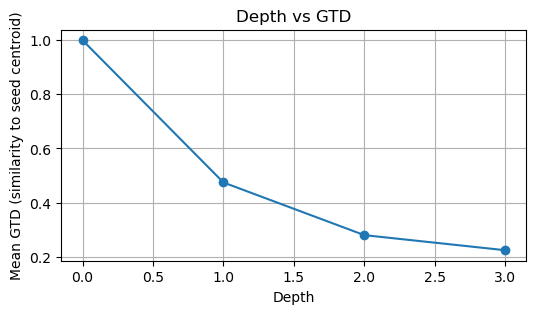

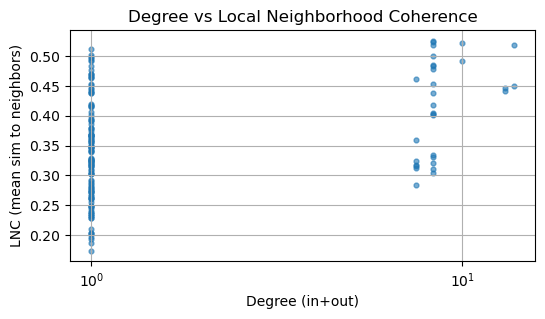

In [73]:
# Small visualizations - mean GTD by depth & LNC vs degree
import matplotlib.pyplot as plt

def plot_depth_gtd(G, node_metrics):
    depth_map = defaultdict(list)
    for n in G.nodes:
        depth_map[int(G.nodes[n].get('depth',0))].append(node_metrics['gtd'][n])
    depths = sorted(depth_map.keys())
    means = [np.nanmean([v for v in depth_map[d] if not math.isnan(v)]) for d in depths]
    plt.figure(figsize=(6,3))
    plt.plot(depths, means, marker='o')
    plt.xlabel("Depth")
    plt.ylabel("Mean GTD (similarity to seed centroid)")
    plt.title("Depth vs GTD")
    plt.grid(True)
    plt.show()

def plot_lnc_vs_degree(G, node_metrics):
    nodes = list(G.nodes)
    degs = np.array([G.out_degree(n) + G.in_degree(n) for n in nodes])
    lnc_vals = np.array([node_metrics['lnc'][n] if not math.isnan(node_metrics['lnc'][n]) else np.nanmean(list(node_metrics['lnc'].values())) for n in nodes])
    plt.figure(figsize=(6,3))
    plt.scatter(degs, lnc_vals, alpha=0.6, s=12)
    plt.xscale('symlog')
    plt.xlabel("Degree (in+out)")
    plt.ylabel("LNC (mean sim to neighbors)")
    plt.title("Degree vs Local Neighborhood Coherence")
    plt.grid(True)
    plt.show()

# Usage:
plot_depth_gtd(G, node_metrics)
plot_lnc_vs_degree(G, node_metrics)


In [74]:
# # Cell 12: Example end-to-end run (execute cell-by-cell instead for exploration)
# # Adjust the file path as needed:
# #INPUT_JSON = "dataforseo-topic-graph.jsonl"
# G, raw = load_graph_from_json(JSON)
# G, model = compute_embeddings(G)
# # compute seed centroid from roots
# seed_nodes = [n for n in G.nodes if G.in_degree(n) == 0] if SEED_ROOT_IDS is None else [str(s) for s in SEED_ROOT_IDS if str(s) in G.nodes]
# seed_nodes = seed_nodes or ["0"]
# seed_centroid = np.mean([G.nodes[n]['embedding'] for n in seed_nodes], axis=0)
# seed_centroid = seed_centroid / (np.linalg.norm(seed_centroid) + 1e-12)

# neighbors = build_knn_index(G, k=K_NEIGHBORS)
# node_metrics = compute_node_metrics(G, neighbors, seed_centroid=seed_centroid)
# global_scores = compute_global_scores(G, node_metrics, neighbors)
# flagged = flag_nodes(G, node_metrics)
# report = create_report(G, node_metrics, global_scores, flagged)

# print("Summary:")
# pprint(report['summary'])
# print("Top flagged nodes:")
# pprint(report['flagged_nodes'][:10])
# # optionally save
# with open("topic_graph_report.json", "w", encoding="utf-8") as fh:
#     json.dump(report, fh, indent=2)


# visualisation

In [75]:
# Cell: Build a DataFrame for easy plotting & sorting
import pandas as pd
import numpy as np

node_list = list(G.nodes)

df = pd.DataFrame({
    "node_id": node_list,
    "uuid": [G.nodes[n]['metadata'].get('uuid') for n in node_list],
    "topic": [G.nodes[n].get('topic','') for n in node_list],
    "depth": [G.nodes[n].get('depth', None) for n in node_list],
    "degree": [G.in_degree(n) + G.out_degree(n) for n in node_list],
    "lnc": [node_metrics['lnc'][n] for n in node_list],
    "na": [node_metrics['na'][n] for n in node_list],
    "gtd": [node_metrics['gtd'][n] for n in node_list],
    "max_sim": [node_metrics['max_sim'][n] for n in node_list],
    "novelty": [node_metrics['novelty'][n] for n in node_list]
})

# Some columns may contain NaNs: keep as-is.
df.head(8)


,node_id,uuid,topic,depth,degree,lnc,na,gtd,max_sim,novelty
0,0,6626b4cf-a8ef-47a4-b824-1062a7b673f8,Generate diverse SEO tasks using 10 core tools...,0,15,0.449196,0.381082,1.000000,0.723598,1.000000
1,1,90f2f47e-7a6f-4fcc-9843-d1dc35c34c26,Understanding Diverse SEO Task Categories,1,14,0.442033,0.418487,0.623410,0.756707,0.497059
2,2,1c856e10-22fb-4346-a743-fd13c8aa5ac0,Key Features of the 10 Core SEO Tools,1,15,0.517692,0.423825,0.676193,0.683508,0.510507
3,3,433e12a4-edc0-4d58-b9f5-11af927cf154,Designing the Single Orchestration Tool for SE...,1,14,0.445589,0.374206,0.596929,0.630077,0.577806
4,4,4c49d51f-8128-4993-bc0f-2846630d082e,Automated Workflow for Generating SEO Tasks,1,10,0.521626,0.409520,0.662964,0.799292,0.514007
5,5,8a20a2c9-a04e-43a6-b3b8-e4964c8fa0ec,Benefits and Challenges of Unified SEO Task Ge...,1,10,0.491991,0.414183,0.626879,0.692547,0.523310
6,6,559f8282-20ce-4225-8210-109b15ae09bd,Architecture of the Orchestration Tool,2,7,0.317462,0.254916,0.201981,0.912527,0.788384
7,7,629f8b0f-61e3-4ab6-b3e3-413fa5d4aea5,Defining Task Inputs and Outputs for Orchestra...,2,7,0.311650,0.235898,0.251254,0.756683,0.790067


In [76]:
# compute ancestor_at_absolute_depth columns
# Semantic: ancestor_at_level_D stores the node id of the ancestor that sits at depth (D).

from collections import deque

# find max depth in graph
max_depth = int(df['depth'].max()) if not df['depth'].isna().all() else 0
max_level = max_depth  # we'll compute levels 1..max_level

def ancestor_at_absolute_depth(node_id, target_depth):
    """
    Return the ancestor of node_id whose depth == target_depth, walking parents up.
    target_depth is absolute depth (0-based). Returns None if not found.
    """
    cur = str(node_id)
    cur_depth = G.nodes[cur].get('depth', None)
    if cur_depth is None:
        return None
    if cur_depth < target_depth:
        return None  # node is shallower than target depth
    # walk up until we find node at target_depth
    # guard: prevent infinite loops using visited set
    visited = set()
    while True:
        if cur in visited:
            return None
        visited.add(cur)
        d = G.nodes[cur].get('depth', None)
        if d == target_depth:
            return cur
        # step up: choose first parent if multiple (consistent with graph creation)
        parents = G.nodes[cur].get('parents', []) or []
        if not parents:
            return None
        cur = str(parents[0])
        # loop continues until depth matches or runs out

# compute columns for levels 0..max_level
for D in range(0, max_level + 1):
    col_node = f"parent_node_at_level_{D}"
    #col_uuid = f"ancestor_uuid_level_{D}"
    vals_node = []
    vals_uuid = []
    target_depth = D 
    for nid in df['node_id']:
        anc = ancestor_at_absolute_depth(nid, target_depth)
        vals_node.append(anc)
        vals_uuid.append(G.nodes[anc]['metadata'].get('uuid') if anc is not None else None)
    df[col_node] = vals_node
    #df[col_uuid] = vals_uuid

# quick check: show a few rows
df.head(12)



,node_id,uuid,topic,depth,degree,lnc,na,gtd,max_sim,novelty,parent_node_at_level_0,parent_node_at_level_1,parent_node_at_level_2,parent_node_at_level_3
0,0,6626b4cf-a8ef-47a4-b824-1062a7b673f8,Generate diverse SEO tasks using 10 core tools...,0,15,0.449196,0.381082,1.000000,0.723598,1.000000,0,None,None,None
1,1,90f2f47e-7a6f-4fcc-9843-d1dc35c34c26,Understanding Diverse SEO Task Categories,1,14,0.442033,0.418487,0.623410,0.756707,0.497059,0,1,None,None
2,2,1c856e10-22fb-4346-a743-fd13c8aa5ac0,Key Features of the 10 Core SEO Tools,1,15,0.517692,0.423825,0.676193,0.683508,0.510507,0,2,None,None
3,3,433e12a4-edc0-4d58-b9f5-11af927cf154,Designing the Single Orchestration Tool for SE...,1,14,0.445589,0.374206,0.596929,0.630077,0.577806,0,3,None,None
4,4,4c49d51f-8128-4993-bc0f-2846630d082e,Automated Workflow for Generating SEO Tasks,1,10,0.521626,0.409520,0.662964,0.799292,0.514007,0,4,None,None
5,5,8a20a2c9-a04e-43a6-b3b8-e4964c8fa0ec,Benefits and Challenges of Unified SEO Task Ge...,1,10,0.491991,0.414183,0.626879,0.692547,0.523310,0,5,None,None
6,6,559f8282-20ce-4225-8210-109b15ae09bd,Architecture of the Orchestration Tool,2,7,0.317462,0.254916,0.201981,0.912527,0.788384,0,3,6,None
7,7,629f8b0f-61e3-4ab6-b3e3-413fa5d4aea5,Defining Task Inputs and Outputs for Orchestra...,2,7,0.311650,0.235898,0.251254,0.756683,0.790067,0,3,7,None
8,8,0b07a070-d25b-4248-9f61-4f845e480f5a,Integration APIs and Connectors for 10 Core Tools,2,7,0.360048,0.263052,0.479732,0.723218,0.756909,0,3,8,None
9,9,4efdf866-67d0-4413-8239-a695696d291e,Workflow Engine and Task Scheduling Logic,2,7,0.316032,0.263081,0.199512,0.748136,0.732392,0,3,9,None


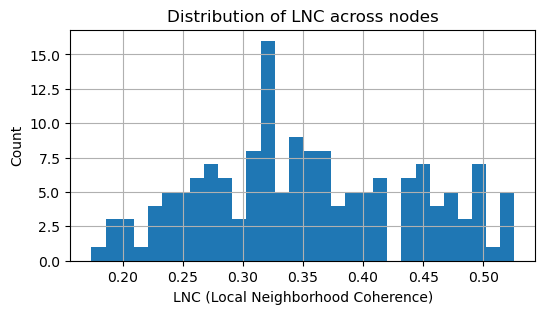

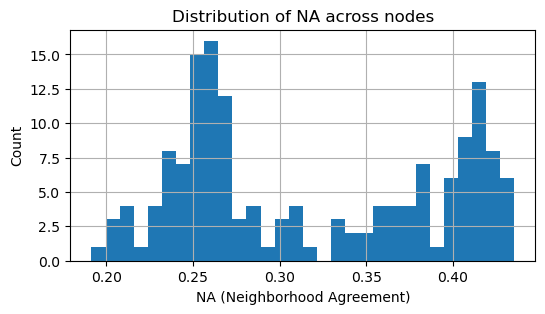

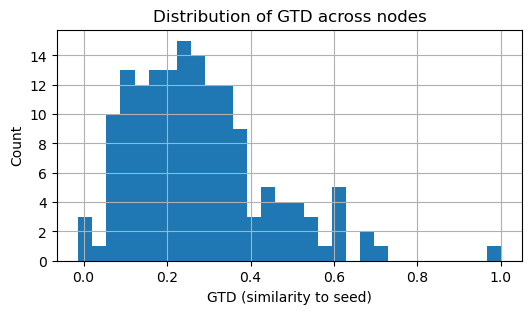

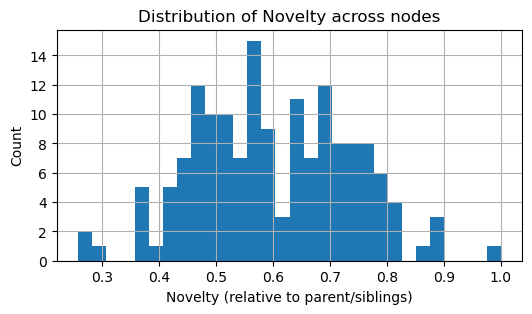

In [77]:
# Cell: Histogram of LNC
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.hist(df['lnc'].dropna().values, bins=30)
plt.xlabel("LNC (Local Neighborhood Coherence)")
plt.ylabel("Count")
plt.title("Distribution of LNC across nodes")
plt.grid(True)
plt.show()

# Cell: Histogram of NA (neighborhood agreement)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.hist(df['na'].dropna().values, bins=30)
plt.xlabel("NA (Neighborhood Agreement)")
plt.ylabel("Count")
plt.title("Distribution of NA across nodes")
plt.grid(True)
plt.show()

# Cell: Histogram of GTD (similarity to seed centroid)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.hist(df['gtd'].dropna().values, bins=30)
plt.xlabel("GTD (similarity to seed)")
plt.ylabel("Count")
plt.title("Distribution of GTD across nodes")
plt.grid(True)
plt.show()

# Cell: Histogram of Novelty
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.hist(df['novelty'].dropna().values, bins=30)
plt.xlabel("Novelty (relative to parent/siblings)")
plt.ylabel("Count")
plt.title("Distribution of Novelty across nodes")
plt.grid(True)
plt.show()

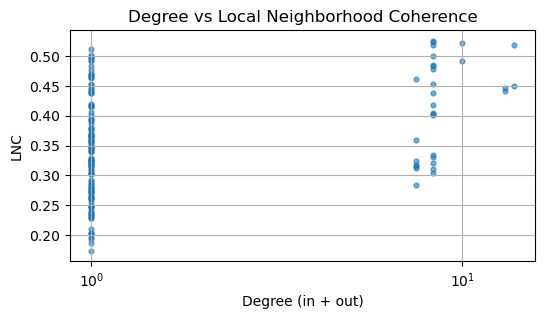

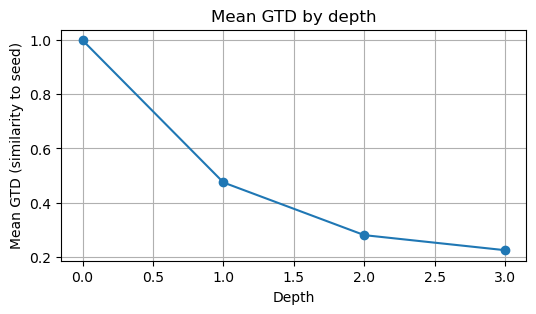

,depth,mean,count
0,0,1.000000,1
1,1,0.474288,15
2,2,0.279699,65
3,3,0.223983,75


In [78]:
# Cell: Scatter LNC vs Degree (navigability check)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.scatter(df['degree'], df['lnc'], s=12, alpha=0.6)
plt.xscale('symlog')  # shows small & large degrees nicely
plt.xlabel("Degree (in + out)")
plt.ylabel("LNC")
plt.title("Degree vs Local Neighborhood Coherence")
plt.grid(True)
plt.show()

# Cell: Mean GTD by depth
import matplotlib.pyplot as plt
depth_groups = df.groupby('depth')['gtd'].agg(['mean','count']).reset_index().dropna()
plt.figure(figsize=(6,3))
plt.plot(depth_groups['depth'], depth_groups['mean'], marker='o')
plt.xlabel("Depth")
plt.ylabel("Mean GTD (similarity to seed)")
plt.title("Mean GTD by depth")
plt.grid(True)
plt.show()

# also display the table
depth_groups

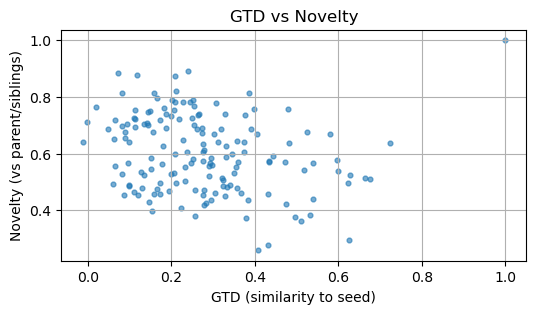

In [79]:
# Cell: GTD vs Novelty
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.scatter(df['gtd'], df['novelty'], s=12, alpha=0.6)
plt.xlabel("GTD (similarity to seed)")
plt.ylabel("Novelty (vs parent/siblings)")
plt.title("GTD vs Novelty")
plt.grid(True)
plt.show()

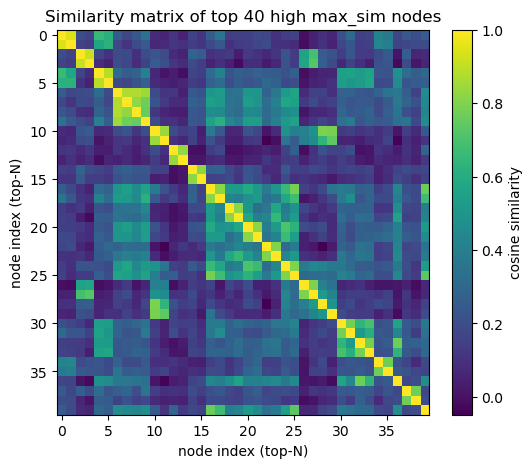

In [80]:
# Cell: Similarity heatmap for top-N potentially redundant nodes
import numpy as np
import matplotlib.pyplot as plt

TOP_N = 40
top_dup = df.sort_values('max_sim', ascending=False).head(TOP_N)
ids = top_dup['node_id'].tolist()
embs = np.vstack([G.nodes[n]['embedding'] for n in ids])
# cosine similarity matrix (embeddings should be normalized)
sim_mat = embs @ embs.T

plt.figure(figsize=(6,5))
plt.imshow(sim_mat, interpolation='nearest', aspect='auto')
plt.colorbar(label='cosine similarity')
plt.title(f"Similarity matrix of top {TOP_N} high max_sim nodes")
plt.xlabel("node index (top-N)")
plt.ylabel("node index (top-N)")
plt.show()


In [ ]:
# Cell: PCA projection of embeddings, colored by GTD
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

node_list = list(G.nodes)
emb_arr = np.vstack([G.nodes[n]['embedding'] for n in node_list])

pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(emb_arr)

plt.figure(figsize=(6,4))
plt.scatter(proj[:,0], proj[:,1], c=df['gtd'].fillna(df['gtd'].mean()).values, s=10, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of node embeddings (color = GTD)")
plt.colorbar(label="GTD")
plt.grid(True)
plt.show()

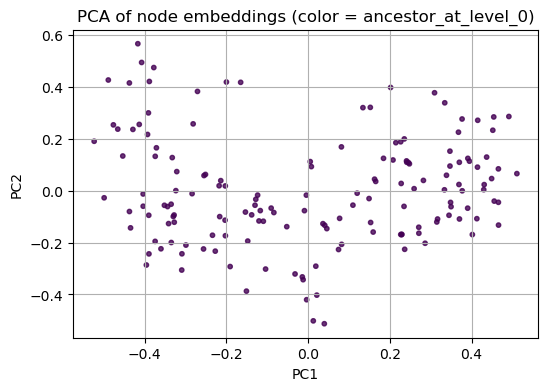

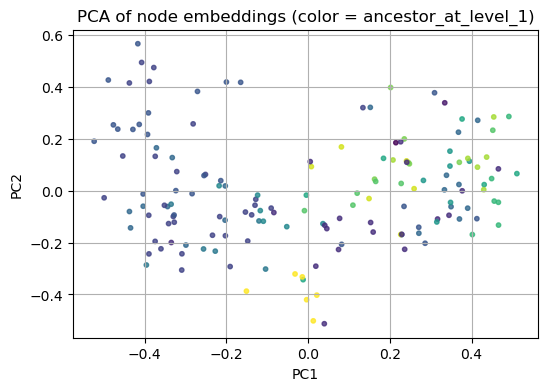

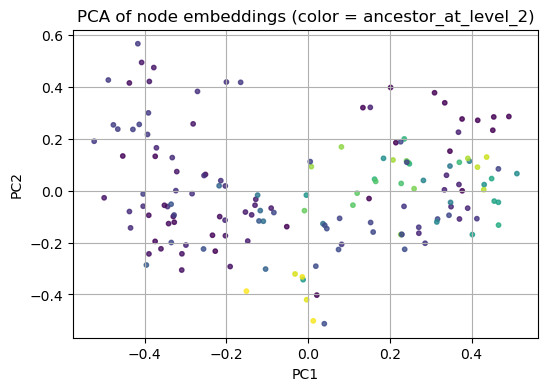

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA once
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(emb_arr)

# how many levels to plot
max_level = int(df['depth'].max())

for D in range(0, max_level):
    col = f"parent_node_at_level_{D}"
    if col not in df.columns:
        continue

    plt.figure(figsize=(6,4))
    plt.scatter(
        proj[:,0],
        proj[:,1],
        c=pd.factorize(df[col].fillna("ROOT"))[0],
        s=10,
        alpha=0.8
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA of node embeddings (color = ancestor_at_level_{D})")
    plt.grid(True)
    plt.show()


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA once
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(emb_arr)

max_level = int(df['depth'].max())

for D in range(0, max_level):
    col = f"parent_node_at_level_{D}"
    if col not in df.columns:
        continue

    plt.figure(figsize=(6,4))

    # group by parent at this level
    for parent, idx in df.groupby(col).groups.items():
        label = str(parent) if parent is not None else "ROOT"
        plt.scatter(
            proj[idx, 0],
            proj[idx, 1],
            s=10,
            alpha=0.8,
            label=label
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA of node embeddings (color = ancestor_at_level_{D})")
    plt.legend(
        title="Parent node",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize="small"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# UMAP projection + loop plotting colored by ancestor_at_level_D (no KMeans)
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# compute projection: try UMAP, fallback to PCA
try:
    import umap
    umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    proj = umap_model.fit_transform(emb_arr)
    method = "umap"
except Exception as e:
    print("UMAP failed, falling back to PCA:", type(e).__name__, str(e)[:200])
    pca = PCA(n_components=2, random_state=0)
    proj = pca.fit_transform(emb_arr)
    method = "pca"

df['proj_x'] = proj[:,0]
df['proj_y'] = proj[:,1]

# loop over ancestor levels and plot
max_level = int(df['depth'].max()) if not df['depth'].isna().all() else 0
print(max_level)
for D in range(0, max_level):
    col = f"parent_node_at_level_{D}"
    if col not in df.columns:
        continue

    plt.figure(figsize=(7,5))
    # plot group-by so legend shows mapping parent -> color
    grouped = df.groupby(col)
    for parent, group in grouped:
        label = str(parent) if parent is not None else "ROOT"
        plt.scatter(group['proj_x'], group['proj_y'], s=12, alpha=0.85, label=label)

    plt.title(f"{method.upper()} projection colored by ancestor_at_level_{D}")
    plt.xlabel("proj_x"); plt.ylabel("proj_y")
    plt.legend(title="Parent node", bbox_to_anchor=(1.02,1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

3


/Users/kexinxu/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
## K means
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# PCA once
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(emb_arr)

max_level = int(df['depth'].max())
n_clusters = 10   # choose as you like

# KMeans once (on embeddings, not PCA)
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(emb_arr)
df['kmeans_cluster'] = clusters

for D in range(0, max_level):
    col = f"parent_node_at_level_{D}"
    if col not in df.columns:
        continue

    plt.figure(figsize=(6,4))

    for c in range(n_clusters):
        idx = df.index[df['kmeans_cluster'] == c]

        # find dominant parent at this level for the cluster
        parents = df.loc[idx, col].fillna("ROOT")
        dominant_parent = parents.value_counts().idxmax()

        plt.scatter(
            proj[idx, 0],
            proj[idx, 1],
            s=10,
            alpha=0.8,
            label=f"cluster {c} → parent {dominant_parent}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA + KMeans (color = cluster, label = ancestor_at_level_{D})")
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize="small"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/Users/kexinxu/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP OK in 2.35s


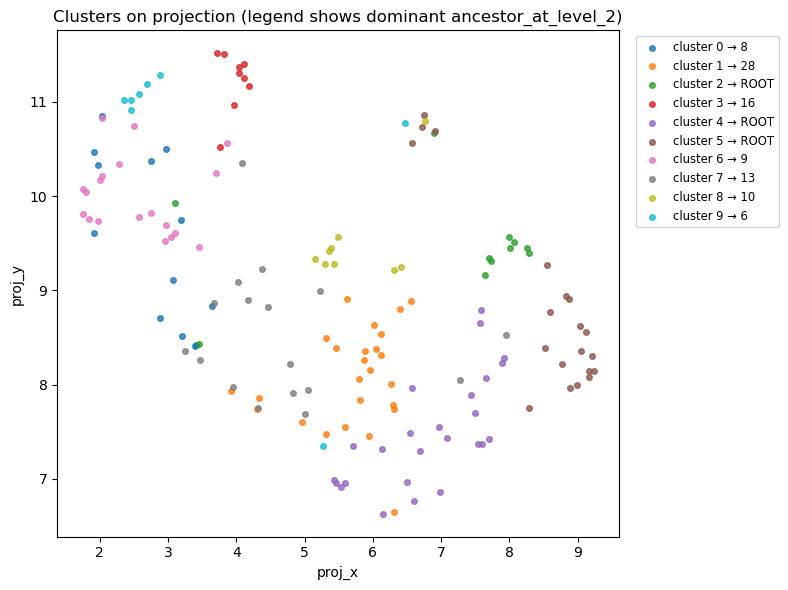

In [ ]:
# UMAP projection + cluster visualization (with dominant-parent legend)
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# CONFIG
D = 2                  # ancestor level to use in legend (change as needed)
n_clusters = 10        # will create kmeans if df lacks 'kmeans_cluster'
umap_params = {"n_components":2, "n_neighbors":15, "min_dist":0.1, "metric":"cosine", "random_state":42}

# ensure clusters exist
if 'kmeans_cluster' not in df.columns:
    km = KMeans(n_clusters=n_clusters, random_state=0).fit(emb_arr)
    df['kmeans_cluster'] = km.labels_

# compute projection (UMAP if available, otherwise PCA)
proj_ok = False
try:
    import umap
    start = time.time()
    umap_model = umap.UMAP(**umap_params)
    proj = umap_model.fit_transform(emb_arr)
    print("UMAP OK in {:.2f}s".format(time.time()-start))
    proj_ok = True
except Exception as e:
    print("UMAP failed (fallback to PCA):", type(e).__name__, str(e)[:200])
    pca = PCA(n_components=2, random_state=0)
    proj = pca.fit_transform(emb_arr)

df['proj_x'] = proj[:,0]
df['proj_y'] = proj[:,1]

# plotting clusters, legend shows dominant parent at level D
col = f"parent_node_at_level_{D}"
if col not in df.columns:
    print(f"Warning: {col} not in df — legend will show 'UNKNOWN' parents.")

plt.figure(figsize=(8,6))
for c in sorted(df['kmeans_cluster'].unique()):
    sel = df[df['kmeans_cluster'] == c]
    # dominant parent for this cluster
    if col in df.columns:
        dominant = str(sel[col].fillna("ROOT").value_counts().idxmax())
    else:
        dominant = "UNKNOWN"
    plt.scatter(sel['proj_x'], sel['proj_y'], s=16, alpha=0.8, label=f"cluster {c} → {dominant}")

plt.title(f"Clusters on projection (legend shows dominant ancestor_at_level_{D})")
plt.xlabel("proj_x"); plt.ylabel("proj_y")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize="small")
plt.tight_layout()
plt.show()


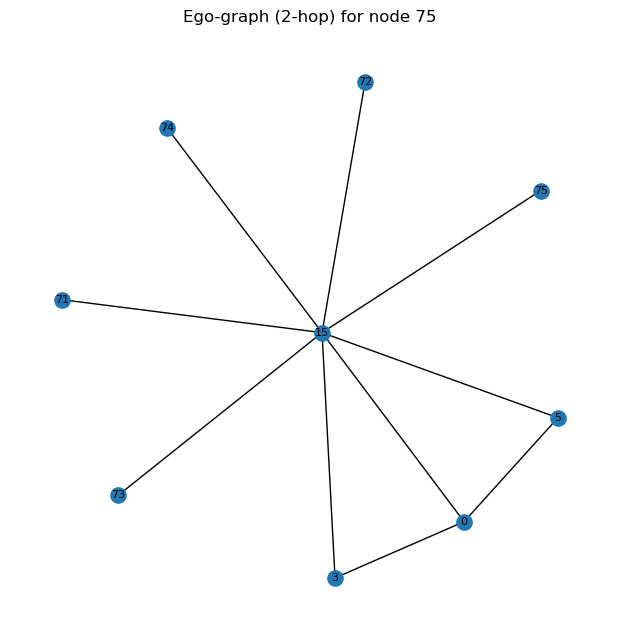

72 | depth: 2 | lnc: 0.20403066039085388 | gtd: 0.04729805514216423
15 | depth: 1 | lnc: 0.3112677597999573 | gtd: 0.3064916729927063
73 | depth: 2 | lnc: 0.28124645471572873 | gtd: 0.33032602071762085
0 | depth: 0 | lnc: 0.4491955816745758 | gtd: 1.000000238418579
3 | depth: 1 | lnc: 0.4455894887447357 | gtd: 0.5969294309616089
75 | depth: 2 | lnc: 0.17390266180038452 | gtd: 0.08039513975381851
74 | depth: 2 | lnc: 0.24379977345466614 | gtd: 0.08034811913967133
71 | depth: 2 | lnc: 0.24800512313842774 | gtd: 0.37388622760772705
5 | depth: 1 | lnc: 0.4919906485080719 | gtd: 0.626879096031189


In [ ]:
# Cell: Ego-graph inspector
import networkx as nx
import matplotlib.pyplot as plt

# pick a node to inspect: e.g., worst by LNC or pick manually
worst_lnc_node = df.sort_values('lnc', ascending=True).iloc[0]['node_id']
inspect_node = worst_lnc_node  # or set manually: inspect_node = '23'

H = nx.ego_graph(G.to_undirected(), inspect_node, radius=2)  # 2-hop ego graph
pos = nx.spring_layout(H, seed=1)  # layout

plt.figure(figsize=(6,6))
nx.draw(H, pos, with_labels=True, node_size=120, font_size=8)
plt.title(f"Ego-graph (2-hop) for node {inspect_node}")
plt.show()

# Print node info for each member
for n in H.nodes:
    print(n, "| depth:", G.nodes[n].get('depth'), "| lnc:", node_metrics['lnc'].get(n), "| gtd:", node_metrics['gtd'].get(n))


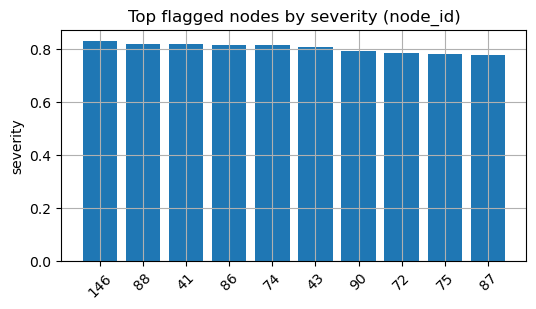

146 995e1d8e-f1a6-4f0a-a78c-62061b8ad3fa ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'] {'lnc': 0.1549546361887591, 'gtd': 0.0716074819327135, 'novelty': 0.31769830338631055, 'dup_sim': 0.7129522562026978}
88 70b78cfe-ea42-4345-a63c-b741653a7281 ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'] {'lnc': 0.1757885216190009, 'gtd': 0.09873751591838244, 'novelty': 0.2612560293729787, 'dup_sim': 0.7053141593933105}
41 d6bf7978-9074-4e10-b200-ee07e49e581a ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'] {'lnc': 0.166330515640018, 'gtd': 0.00982922280426043, 'novelty': 0.6100735402458999, 'dup_sim': 0.7053141593933105}
86 a2dd792e-bed7-4764-8edb-4dad4dd78595 ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'] {'lnc': 0.10243507604772648, 'gtd': 0.11032796566896141, 'novelty': 0.3042536680685044, 'dup_sim': 0.6058851480484009}
74 3f3855de-70e2-49d6-af6a-21971e558235 ['LOW_LNC', 'LOW_NEIGH_AGREEMENT', 'OFF_TOPIC_DRIFT'] {'lnc': 0.19867510145745007, 'gtd': 0.0922776905601672, '

In [ ]:
# Cell: Top flagged nodes bar chart
import matplotlib.pyplot as plt

# Ensure 'flagged' exists; otherwise compute
try:
    flagged_list = flagged  # from earlier
except NameError:
    flagged_list = flag_nodes(G, node_metrics)

topk = flagged_list[:10]
labels = [f"{f['node_id']}" for f in topk]
sevs = [f['severity'] for f in topk]

plt.figure(figsize=(6,3))
plt.bar(range(len(sevs)), sevs)
plt.xticks(range(len(sevs)), labels, rotation=45)
plt.ylabel("severity")
plt.title("Top flagged nodes by severity (node_id)")
plt.grid(True)
plt.show()

# print details
for f in topk:
    print(f["node_id"], f["uuid"], f["reasons"], f["scores"])


## UMAP of Embedding

In [ ]:
# Cell 1: Prepare dataframe & embedding array (run first)
import numpy as np
import pandas as pd

node_list = list(G.nodes)
# ensure embeddings exist
missing = [n for n in node_list if 'embedding' not in G.nodes[n]]
if missing:
    raise RuntimeError(f"Missing embeddings for {len(missing)} nodes; run embedding step first. Examples: {missing[:5]}")

emb_arr = np.vstack([G.nodes[n]['embedding'] for n in node_list])
df = pd.DataFrame({
    "node_id": node_list,
    "uuid": [G.nodes[n]['metadata'].get('uuid') for n in node_list],
    "topic": [G.nodes[n].get('topic','') for n in node_list],
    "depth": [G.nodes[n].get('depth', None) for n in node_list],
    "degree": [G.in_degree(n) + G.out_degree(n) for n in node_list],
    "lnc": [node_metrics['lnc'].get(n, np.nan) for n in node_list],
    "na": [node_metrics['na'].get(n, np.nan) for n in node_list],
    "gtd": [node_metrics['gtd'].get(n, np.nan) for n in node_list],
    "max_sim": [node_metrics['max_sim'].get(n, np.nan) for n in node_list],
    "novelty": [node_metrics['novelty'].get(n, np.nan) for n in node_list],
    # parent: pick first parent if multiple, else 'root' if none
    "parent": [ (G.nodes[n].get('parents') or [None])[0] if G.nodes[n].get('parents') else None for n in node_list ]
})
# replace None parent values with 'ROOT' string for plotting
df['parent_cat'] = df['parent'].fillna('ROOT').astype(str)
print("Prepared df and embeddings:", emb_arr.shape, "nodes:", len(df))
df.head(5)


Prepared df and embeddings: (156, 384) nodes: 156


,node_id,uuid,topic,depth,degree,lnc,na,gtd,max_sim,novelty,parent,parent_cat
0,0,6626b4cf-a8ef-47a4-b824-1062a7b673f8,Generate diverse SEO tasks using 10 core tools...,0,15,0.449196,0.381082,1.000000,0.723598,1.000000,None,ROOT
1,1,90f2f47e-7a6f-4fcc-9843-d1dc35c34c26,Understanding Diverse SEO Task Categories,1,14,0.442033,0.418487,0.623410,0.756707,0.497059,0,0
2,2,1c856e10-22fb-4346-a743-fd13c8aa5ac0,Key Features of the 10 Core SEO Tools,1,15,0.517692,0.423825,0.676193,0.683508,0.510507,0,0
3,3,433e12a4-edc0-4d58-b9f5-11af927cf154,Designing the Single Orchestration Tool for SE...,1,14,0.445589,0.374206,0.596929,0.630077,0.577806,0,0
4,4,4c49d51f-8128-4993-bc0f-2846630d082e,Automated Workflow for Generating SEO Tasks,1,10,0.521626,0.409520,0.662964,0.799292,0.514007,0,0


In [ ]:
# Cell 2: Compute UMAP projection (2D)
import umap
import time

# UMAP params - tweak if you want different granularity
n_neighbors = 15
min_dist = 0.1
metric = 'cosine'   # embeddings are cosine-friendly

start = time.time()
umap_model = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
proj = umap_model.fit_transform(emb_arr)
print("UMAP done in {:.2f}s; proj shape: {}".format(time.time() - start, proj.shape))

# attach to dataframe
df['umap_x'] = proj[:,0]
df['umap_y'] = proj[:,1]

UMAP done in 0.15s; proj shape: (156, 2)


/Users/kexinxu/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


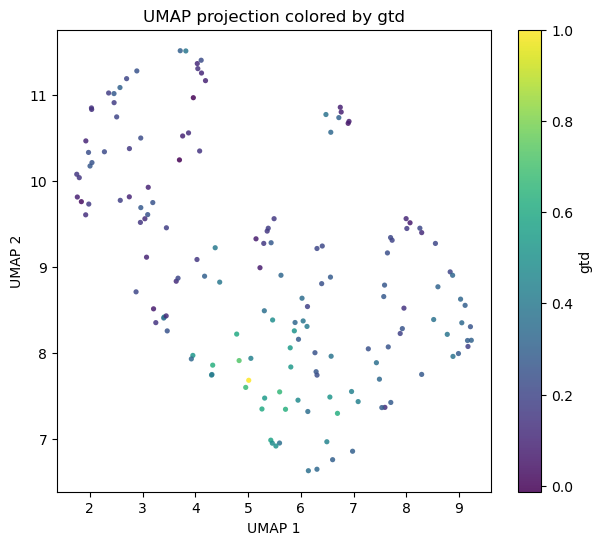

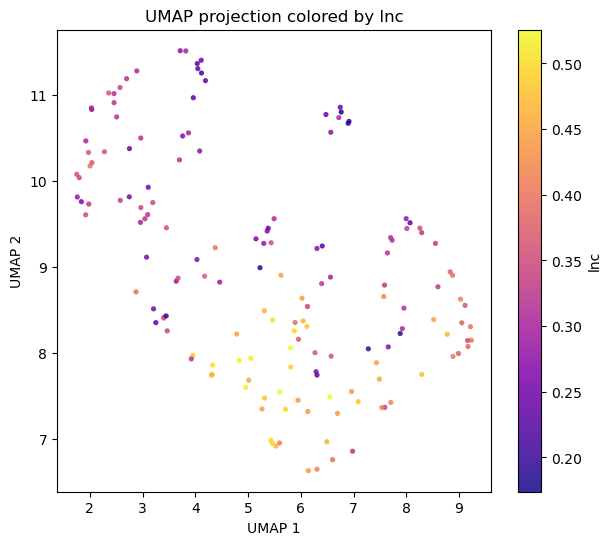

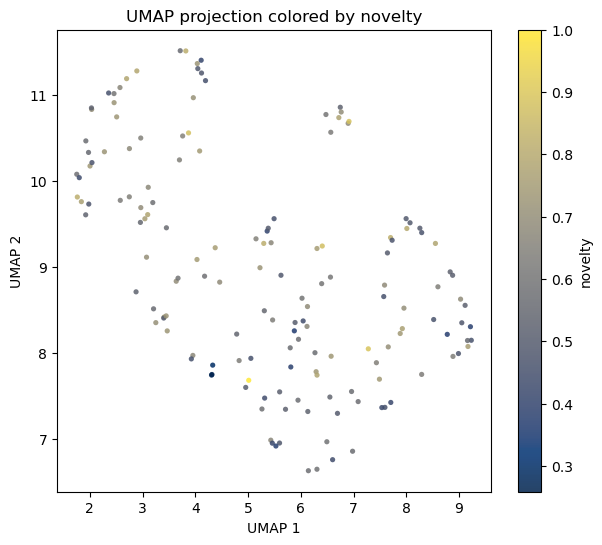

In [ ]:
# Cell 3: Plot UMAP colored by numeric metric helper function
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_umap_numeric(df, metric='gtd', cmap='viridis', size=18, savepath=None):
    vals = df[metric].fillna(df[metric].mean()).values
    norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    plt.figure(figsize=(7,6))
    sc = plt.scatter(df['umap_x'], df['umap_y'], c=vals, cmap=cmap, s=size, alpha=0.85, edgecolors='none')
    plt.colorbar(sc, label=metric)
    plt.title(f"UMAP projection colored by {metric}")
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.grid(False)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()

# Examples (run each cell separately to view):
plot_umap_numeric(df, metric='gtd', cmap='viridis', size=14)
plot_umap_numeric(df, metric='lnc', cmap='plasma', size=14)
plot_umap_numeric(df, metric='novelty', cmap='cividis', size=14)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


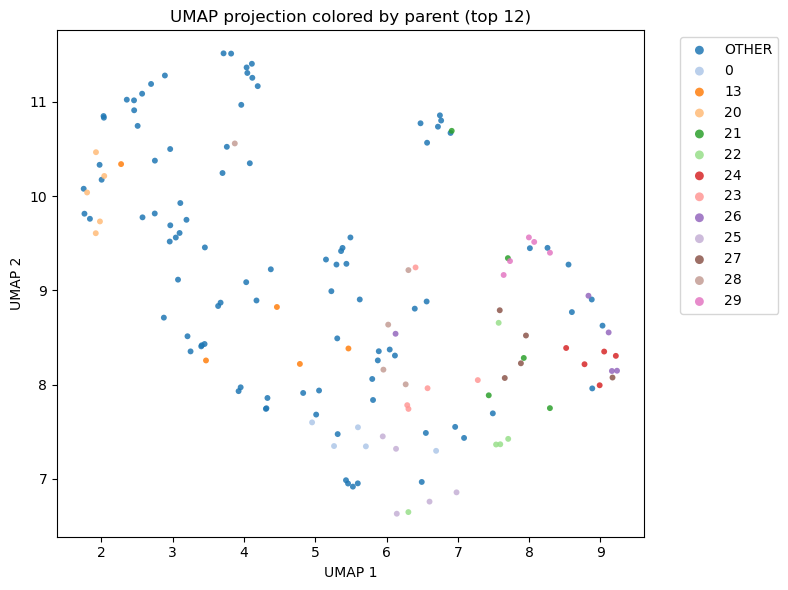

In [ ]:
# Cell 4: Plot UMAP colored by categorical parent (top-K parents + 'OTHER' grouping)
import matplotlib.pyplot as plt
import seaborn as sns

def plot_umap_parent(df, top_k=10, size=20, savepath=None):
    # determine top-k parents by frequency
    parent_counts = df['parent_cat'].value_counts()
    top_parents = parent_counts.index[:top_k].tolist()
    # create a column for plotting: keep top_k as-is, group rest as OTHER
    df['parent_plot'] = df['parent_cat'].apply(lambda p: p if p in top_parents else 'OTHER')
    # palette
    unique_parents = df['parent_plot'].unique().tolist()
    palette = sns.color_palette('tab20', n_colors=max(len(unique_parents), 8))
    color_map = {p: palette[i % len(palette)] for i,p in enumerate(unique_parents)}

    plt.figure(figsize=(8,6))
    for p in unique_parents:
        sel = df[df['parent_plot'] == p]
        plt.scatter(sel['umap_x'], sel['umap_y'], s=size, color=color_map[p], alpha=0.85, label=p, edgecolors='none')
    plt.legend(markerscale=1.5, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"UMAP projection colored by parent (top {top_k})")
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()

# Example:
plot_umap_parent(df, top_k=12, size=18)

In [ ]:
# -----------------------
# PARAMETERS / THRESHOLDS
# -----------------------
EMBED_MODEL = "all-MiniLM-L6-v2"
K_NEIGHBORS = 50          # neighbors to compute local metrics (cap at n-1)
SAMPLED_PAIRWISE = 5000   # number of random pairs to estimate global pairwise similarity
CLUSTER_K = None          # if None, will choose based on N
SEED_ROOT_IDS = None      # if None, script will use graph roots as seeds for centroid
# Thresholds (tune per domain)
TAU_LNC = 0.50            # local neighborhood coherence threshold
TAU_NA = 0.40             # neighborhood agreement
TAU_GTD = 0.40            # on-message drift threshold
TAU_DUP = 0.92            # duplicate similarity threshold (embedding cosine)
TAU_NOVELTY = 0.20       # novelty threshold
CVC_SLOPE_BAD = -0.05     # slope threshold for coherence vs degree
DCD_BAD = 0.08            # depth coherence decay per level considered bad

# weights for severity scoring
SEV_WEIGHTS = {
    "lnc": 0.35,
    "gtd": 0.35,
    "dup": 0.2,
    "novelty": 0.1
}

# -----------------------
# Helper utilities
# -----------------------
def normalize_to_01(arr, eps=1e-12):
    a = np.array(arr, dtype=float)
    lo = np.nanmin(a)
    hi = np.nanmax(a)
    if math.isclose(hi, lo):
        return np.clip((a - lo), 0.0, 1.0)  # zeros
    return (a - lo) / (hi - lo + eps)

def cosine_sim_matrix_rowwise(A, B=None):
    # A: (n,d), B: (m,d) or None -> returns sims of A x A
    if B is None:
        B = A
    # assume normalized embeddings; if not, normalize
    A_n = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B_n = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return A_n.dot(B_n.T)

# -----------------------
# Load graph JSON & build NetworkX DiGraph
# -----------------------
def load_graph_from_json(path):
    with open(path, 'r', encoding='utf-8') as fh:
        data = json.load(fh)
    nodes = data['nodes']
    G = nx.DiGraph()
    for node_id, nd in nodes.items():
        # node_id might be numeric keys — convert to string for consistency
        key = str(node_id)
        G.add_node(key,
                   topic=nd.get('topic', '').strip(),
                   metadata=nd.get('metadata', {}),
                   parents=[str(p) for p in nd.get('parents', [])],
                   children=[str(c) for c in nd.get('children', [])])
    # edges
    for n in G.nodes:
        for c in G.nodes[n]['children']:
            if c in G.nodes:
                G.add_edge(n, c)
    # compute/ensure depth if not present
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    if not roots:
        # fallback: pick node "0" if exists
        if "0" in G.nodes:
            roots = ["0"]
        else:
            roots = [list(G.nodes)[0]]
    for root in roots:
        if 'depth' not in G.nodes[root]:
            G.nodes[root]['depth'] = 0
        queue = [root]
        while queue:
            cur = queue.pop(0)
            cur_depth = G.nodes[cur].get('depth', 0)
            for child in G.successors(cur):
                if 'depth' not in G.nodes[child]:
                    G.nodes[child]['depth'] = cur_depth + 1
                    queue.append(child)
    return G, data

# -----------------------
# Compute embeddings
# -----------------------
def compute_embeddings(G, model_name=EMBED_MODEL, cache=None):
    # cache: optional dict uuid->vec to reuse existing embeddings
    model = SentenceTransformer(model_name)
    node_list = list(G.nodes)
    texts = [G.nodes[n]['topic'] if G.nodes[n]['topic'] else G.nodes[n]['metadata'].get('title','') for n in node_list]
    # fallback if empty string: use uuid or id
    for i, t in enumerate(texts):
        if t is None or t.strip() == '':
            texts[i] = G.nodes[node_list[i]]['metadata'].get('uuid', node_list[i])
    embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
    # store embeddings in node attributes
    for i, n in enumerate(node_list):
        G.nodes[n]['embedding'] = embeddings[i]
    return G

# -----------------------
# Neighbors (kNN)
# -----------------------
def build_knn_index(G, k=K_NEIGHBORS):
    node_list = list(G.nodes)
    X = np.vstack([G.nodes[n]['embedding'] for n in node_list])
    k_eff = min(k + 1, len(node_list))  # +1 because first neighbor will be itself
    nn = NearestNeighbors(n_neighbors=k_eff, metric='cosine').fit(X)
    dists, idxs = nn.kneighbors(X)
    # convert distances to cosine sims (sklearn cosine returns [0..2]? Actually returns cosine distance; sim = 1 - dist)
    sims = 1.0 - dists
    neighbors = {}
    for i, n in enumerate(node_list):
        rows = idxs[i].tolist()
        sims_row = sims[i].tolist()
        # remove self (first entry)
        pairs = [(node_list[r], sims_row[j]) for j, r in enumerate(rows) if r != i]
        neighbors[n] = pairs[:k]  # (neighbor_id, sim)
    return neighbors

# -----------------------
# Per-node metrics
# -----------------------
def compute_node_metrics(G, neighbors, seed_centroid=None):
    node_list = list(G.nodes)
    N = len(node_list)
    emb_map = {n: G.nodes[n]['embedding'] for n in node_list}

    lnc = {}
    na = {}
    gtd = {}
    max_sim = {}
    novelty = {}
    for n in node_list:
        neigh_pairs = neighbors.get(n, [])
        neigh_ids = [p[0] for p in neigh_pairs]
        neigh_sims = [p[1] for p in neigh_pairs]
        # LNC: mean sim(node, neighbors)
        if len(neigh_sims) == 0:
            lnc[n] = float('nan')
        else:
            lnc[n] = float(np.mean(neigh_sims))

        # NA: mean pairwise sim among neighbors
        if len(neigh_ids) < 2:
            na[n] = float('nan')
        else:
            M = np.vstack([emb_map[u] for u in neigh_ids])
            sims = cosine_sim_matrix_rowwise(M)
            # exclude diagonal, average upper triangular
            k = sims.shape[0]
            triu_idxs = np.triu_indices(k, k=1)
            if triu_idxs[0].size == 0:
                na[n] = float('nan')
            else:
                na[n] = float(np.mean(sims[triu_idxs]))

        # GTD: similarity to seed centroid
        if seed_centroid is None:
            gtd[n] = float('nan')
        else:
            gtd[n] = float(np.dot(emb_map[n], seed_centroid))  # embeddings normalized -> cosine

        # max_sim to any neighbor (dup check)
        if len(neigh_pairs) == 0:
            max_sim[n] = 0.0
        else:
            max_sim[n] = max([s for (_, s) in neigh_pairs])

        # novelty: compare to parents and siblings (if available)
        parents = G.nodes[n].get('parents', [])
        siblings = []
        for p in parents:
            # siblings are children of parent excluding self
            for c in G.nodes[p]['children']:
                if c != n:
                    siblings.append(c)
        comps = []
        if len(parents) > 0:
            comps += [np.dot(emb_map[n], emb_map[p]) for p in parents if p in emb_map]
        if len(siblings) > 0:
            comps += [np.dot(emb_map[n], emb_map[s]) for s in siblings if s in emb_map]
        if len(comps) == 0:
            novelty[n] = 1.0  # nothing to compare to => novel
        else:
            novelty[n] = 1.0 - float(np.mean(comps))

    return {
        "lnc": lnc,
        "na": na,
        "gtd": gtd,
        "max_sim": max_sim,
        "novelty": novelty
    }

# -----------------------
# Global metrics
# -----------------------
def compute_global_scores(G, node_metrics, neighbors, sample_pairs=SAMPLED_PAIRWISE, cluster_k=CLUSTER_K):
    node_list = list(G.nodes)
    N = len(node_list)
    emb_arr = np.vstack([G.nodes[n]['embedding'] for n in node_list])

    # Coherence global: mean normalized LNC + NA + GTD (ignore NaNs by using nanmean)
    lnc_vals = np.array([node_metrics['lnc'][n] for n in node_list], dtype=float)
    na_vals = np.array([node_metrics['na'][n] for n in node_list], dtype=float)
    gtd_vals = np.array([node_metrics['gtd'][n] for n in node_list], dtype=float)

    # normalize each (0..1)
    lnc_norm = normalize_to_01(np.nan_to_num(lnc_vals, nan=np.nan))
    na_norm = normalize_to_01(np.nan_to_num(na_vals, nan=np.nan))
    gtd_norm = normalize_to_01(np.nan_to_num(gtd_vals, nan=np.nan))
    coherence_global = float(np.nanmean([lnc_norm, na_norm, gtd_norm]))

    # Diversity: estimated pairwise similarity (sampled), cluster entropy, novelty mean, redundancy rate
    # sampled pairwise similarity
    total_pairs = N*(N-1)//2
    pair_sims = []
    if total_pairs <= sample_pairs:
        # compute full matrix (careful with memory)
        sims = cosine_sim_matrix_rowwise(emb_arr)
        # take upper triangle
        iu = np.triu_indices(N, 1)
        all_pairs = sims[iu]
        pair_sims = all_pairs.tolist()
    else:
        # sample random pairs
        for _ in range(sample_pairs):
            i, j = random.randrange(N), random.randrange(N)
            while i == j:
                j = random.randrange(N)
            pair_sims.append(float(np.dot(emb_arr[i], emb_arr[j])))
    mean_pair_sim = float(np.mean(pair_sims))
    diversity_from_pair = 1.0 - mean_pair_sim  # higher => more diverse

    # cluster entropy
    if cluster_k is None:
        # heuristic: K = min(max(5, N//50), 50)
        K = min(max(5, max(1, N // 50)), 50)
    else:
        K = cluster_k
    if N <= K:
        # trivial: each node its own cluster
        norm_entropy = 1.0
    else:
        kmeans = KMeans(n_clusters=K, random_state=0).fit(emb_arr)
        labels = kmeans.labels_
        counts = np.bincount(labels, minlength=K).astype(float)
        probs = counts / counts.sum()
        entropy = -np.sum([p * math.log(p + 1e-12) for p in probs if p > 0])
        max_entropy = math.log(K)
        norm_entropy = entropy / (max_entropy + 1e-12)

    mean_novelty = float(np.mean([node_metrics['novelty'][n] for n in node_list]))
    redundancy_rate = float(np.mean([1.0 if node_metrics['max_sim'][n] > TAU_DUP else 0.0 for n in node_list]))

    diversity_global = float((0.4 * diversity_from_pair) + (0.4 * norm_entropy) + (0.2 * mean_novelty))
    # optional: penalize too-high redundancy
    diversity_global = diversity_global * (1.0 - redundancy_rate)

    # navigability / coherence vs degree: compute avg LNC per degree bin & slope
    degs = np.array([G.out_degree(n) + G.in_degree(n) for n in node_list])
    lnc_for_slope = np.nan_to_num(lnc_vals, nan=np.nanmean(lnc_vals))
    # log-degree bins
    log_deg = np.log1p(degs)
    # linear fit slope of lnc vs log_deg
    try:
        coeffs = np.polyfit(log_deg, lnc_for_slope, 1)
        slope = float(coeffs[0])
    except Exception:
        slope = 0.0

    # depth coherence decay (mean gtd by depth)
    depth_map = defaultdict(list)
    for n in node_list:
        depth_map[int(G.nodes[n].get('depth', 0))].append(node_metrics['gtd'][n])
    depth_means = []
    depth_levels = sorted(depth_map.keys())
    for d in depth_levels:
        vs = [v for v in depth_map[d] if v is not None and not math.isnan(v)]
        if len(vs) == 0:
            depth_means.append(float('nan'))
        else:
            depth_means.append(float(np.mean(vs)))
    # compute slope (decay) across depth_means ignoring nan
    clean = [(d, m) for d, m in zip(depth_levels, depth_means) if not math.isnan(m)]
    if len(clean) >= 2:
        xs = np.array([d for d, _ in clean])
        ys = np.array([m for _, m in clean])
        coeffs = np.polyfit(xs, ys, 1)
        depth_decay = -float(coeffs[0])  # positive if decreasing with depth
    else:
        depth_decay = 0.0

    return {
        "coherence_global": coherence_global,
        "diversity_global": diversity_global,
        "mean_pairwise_sim": mean_pair_sim,
        "norm_cluster_entropy": norm_entropy,
        "mean_novelty": mean_novelty,
        "redundancy_rate": redundancy_rate,
        "cvc_slope": slope,
        "depth_decay": depth_decay
    }

# -----------------------
# Flagging / Severity ranking
# -----------------------
def flag_nodes(G, node_metrics):
    nodes = list(G.nodes)
    # normalize numeric metrics to 0..1 for combination
    lnc_arr = np.array([node_metrics['lnc'][n] if not math.isnan(node_metrics['lnc'][n]) else np.nan for n in nodes])
    gtd_arr = np.array([node_metrics['gtd'][n] if not math.isnan(node_metrics['gtd'][n]) else np.nan for n in nodes])
    novelty_arr = np.array([node_metrics['novelty'][n] for n in nodes])
    dup_arr = np.array([node_metrics['max_sim'][n] for n in nodes])

    lnc_norm = normalize_to_01(np.nan_to_num(lnc_arr, nan=np.nanmean(lnc_arr)))
    gtd_norm = normalize_to_01(np.nan_to_num(gtd_arr, nan=np.nanmean(gtd_arr)))
    novelty_norm = normalize_to_01(novelty_arr)
    dup_norm = dup_arr  # already cosine sim in 0..1

    flagged = []
    for i, n in enumerate(nodes):
        reasons = []
        scores = {
            "lnc": float(lnc_norm[i]),
            "gtd": float(gtd_norm[i]),
            "novelty": float(novelty_norm[i]),
            "dup_sim": float(dup_norm[i])
        }
        # conditions for flags (domain thresholds)
        if (node_metrics['lnc'][n] is not None) and (not math.isnan(node_metrics['lnc'][n])) and node_metrics['lnc'][n] < TAU_LNC:
            reasons.append("LOW_LNC")
        if (node_metrics['na'][n] is not None) and (not math.isnan(node_metrics['na'][n])) and node_metrics['na'][n] < TAU_NA:
            reasons.append("LOW_NEIGH_AGREEMENT")
        if (node_metrics['gtd'][n] is not None) and (not math.isnan(node_metrics['gtd'][n])) and node_metrics['gtd'][n] < TAU_GTD:
            reasons.append("OFF_TOPIC_DRIFT")
        if node_metrics['max_sim'][n] > TAU_DUP:
            reasons.append("DUPLICATE")
        if node_metrics['novelty'][n] < TAU_NOVELTY:
            reasons.append("LOW_NOVELTY")
        if reasons:
            # severity: weighted combination (lower normalized lnc/gtd/novelty -> higher impact, dup higher -> higher)
            severity = (SEV_WEIGHTS['lnc'] * (1.0 - scores['lnc'])
                        + SEV_WEIGHTS['gtd'] * (1.0 - scores['gtd'])
                        + SEV_WEIGHTS['dup'] * (scores['dup_sim'])
                        + SEV_WEIGHTS['novelty'] * (1.0 - scores['novelty']))
            flagged.append({
                "node_id": n,
                "uuid": G.nodes[n]['metadata'].get('uuid'),
                "label": G.nodes[n].get('topic'),
                "reasons": reasons,
                "scores": scores,
                "severity": float(severity)
            })
    # sort flagged by severity desc
    flagged_sorted = sorted(flagged, key=lambda x: x['severity'], reverse=True)
    return flagged_sorted

# -----------------------
# Top-level
# -----------------------
def evaluate_graph(json_path, output_path):
    print("Loading graph...")
    G, raw = load_graph_from_json(json_path)
    N = G.number_of_nodes()
    print(f"Nodes: {N}, Edges: {G.number_of_edges()}")

    # compute embeddings
    print("Computing embeddings...")
    G = compute_embeddings(G)

    # seed centroid: compute mean embedding of roots (or provided seeds)
    if SEED_ROOT_IDS:
        seed_nodes = [str(s) for s in SEED_ROOT_IDS if str(s) in G.nodes]
    else:
        seed_nodes = [n for n in G.nodes if G.in_degree(n) == 0]
    if len(seed_nodes) == 0:
        seed_nodes = ["0"] if "0" in G.nodes else [list(G.nodes)[0]]
    seed_embeddings = np.vstack([G.nodes[n]['embedding'] for n in seed_nodes])
    seed_centroid = np.mean(seed_embeddings, axis=0)
    seed_centroid = seed_centroid / (np.linalg.norm(seed_centroid) + 1e-12)

    print("Building kNN index...")
    neighbors = build_knn_index(G, k=K_NEIGHBORS)

    print("Computing per-node metrics...")
    node_metrics = compute_node_metrics(G, neighbors, seed_centroid=seed_centroid)

    print("Computing global scores...")
    global_scores = compute_global_scores(G, node_metrics, neighbors)

    print("Flagging nodes...")
    flagged = flag_nodes(G, node_metrics)

    # package report
    report = {
        "summary": {
            "nodes": N,
            "edges": G.number_of_edges(),
            "seed_count": len(seed_nodes),
            "coherence_global": global_scores['coherence_global'],
            "diversity_global": global_scores['diversity_global'],
            "mean_pairwise_sim": global_scores['mean_pairwise_sim'],
            "norm_cluster_entropy": global_scores['norm_cluster_entropy'],
            "mean_novelty": global_scores['mean_novelty'],
            "redundancy_rate": global_scores['redundancy_rate'],
            "cvc_slope": global_scores['cvc_slope'],
            "depth_decay": global_scores['depth_decay']
        },
        "flagged_nodes": flagged,
        "node_metrics": {
            n: {
                "lnc": node_metrics['lnc'][n],
                "na": node_metrics['na'][n],
                "gtd": node_metrics['gtd'][n],
                "max_sim": node_metrics['max_sim'][n],
                "novelty": node_metrics['novelty'][n],
                "depth": G.nodes[n].get('depth', None),
                "uuid": G.nodes[n]['metadata'].get('uuid')
            }
            for n in G.nodes
        }
    }

    print(f"Flagged nodes: {len(flagged)}")
    with open(output_path, 'w', encoding='utf-8') as fh:
        json.dump(report, fh, indent=2)

    print(f"Saved report to {output_path}")
    return report

# -----------------------
# If run as script
# -----------------------
if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser(description="Evaluate topic graph coherence & diversity")
    parser.add_argument("--input", "-i", required=True, help="Path to topic graph JSON")
    parser.add_argument("--output", "-o", default="topic_graph_report.json", help="Output JSON report path")
    args = parser.parse_args()
    evaluate_graph(args.input, args.output)

usage: ipykernel_launcher.py [-h] --input INPUT [--output OUTPUT]
ipykernel_launcher.py: error: the following arguments are required: --input/-i


SystemExit: 2

/Users/kexinxu/anaconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
